<a href="https://colab.research.google.com/github/de-Zest/python-ai-governance/blob/main/phase3-llm-evaluation/01_consistency_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3 — Consistency Testing
Goal: Measure how consistent gemini-flash-latest is across repeated prompts
Date: May 2026
Status: In Progress

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from google import genai
from google.colab import userdata, drive
import os

# Mount Drive
drive.mount('/content/drive', force_remount=True)
SAVE_PATH = "/content/drive/MyDrive/python-ai-governance/data/"
os.makedirs(SAVE_PATH, exist_ok=True)

# Setup
client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

# Function 1 - Ask LLM
def ask_llm(prompt):
    response = client.models.generate_content(
        model="gemini-flash-latest",
        contents=prompt
    )
    return response.text

# Function 2 - Consistency test
def consistency_test(prompt, runs=3, label="Test"):
    print(f"\n====== CONSISTENCY TEST: {label} ======")
    print(f"Prompt: {prompt}")
    print(f"Runs: {runs}")
    print("=" * 50)

    results = []

    for i in range(runs):
        response = ask_llm(prompt)
        word_count = len(response.split())
        results.append({
            "run": i + 1,
            "prompt": prompt,
            "response": response,
            "word_count": word_count,
        })
        print(f"Run {i+1}: {word_count} words")
        time.sleep(2)

    df = pd.DataFrame(results)

    avg_words = df["word_count"].mean()
    std_words = df["word_count"].std()
    min_words = df["word_count"].min()
    max_words = df["word_count"].max()
    variance = max_words - min_words

    print(f"\n--- Consistency Metrics ---")
    print(f"Average length:   {avg_words:.0f} words")
    print(f"Std deviation:    {std_words:.1f}")
    print(f"Min:              {min_words} words")
    print(f"Max:              {max_words} words")
    print(f"Variance range:   {variance} words")

    if variance < 50:
        print(f"Verdict:          ✅ CONSISTENT")
    elif variance < 150:
        print(f"Verdict:          ⚠️  MODERATE VARIANCE")
    else:
        print(f"Verdict:          ❌ HIGH VARIANCE")

    return df

# Run tests
df1 = consistency_test(
    "What is AI governance in two sentences?",
    runs=3,
    label="Short Definition"
)

time.sleep(3)

df2 = consistency_test(
    "What are the main risks of unregulated AI?",
    runs=3,
    label="Open Ended Question"
)

Mounted at /content/drive

====== CONSISTENCY TEST: Short Definition ======
Prompt: What is AI governance in two sentences?
Runs: 3
Run 1: 47 words
Run 2: 44 words
Run 3: 46 words

--- Consistency Metrics ---
Average length:   46 words
Std deviation:    1.5
Min:              44 words
Max:              47 words
Variance range:   3 words
Verdict:          ✅ CONSISTENT

====== CONSISTENCY TEST: Open Ended Question ======
Prompt: What are the main risks of unregulated AI?
Runs: 3
Run 1: 663 words
Run 2: 647 words
Run 3: 672 words

--- Consistency Metrics ---
Average length:   661 words
Std deviation:    12.7
Min:              647 words
Max:              672 words
Variance range:   25 words
Verdict:          ✅ CONSISTENT


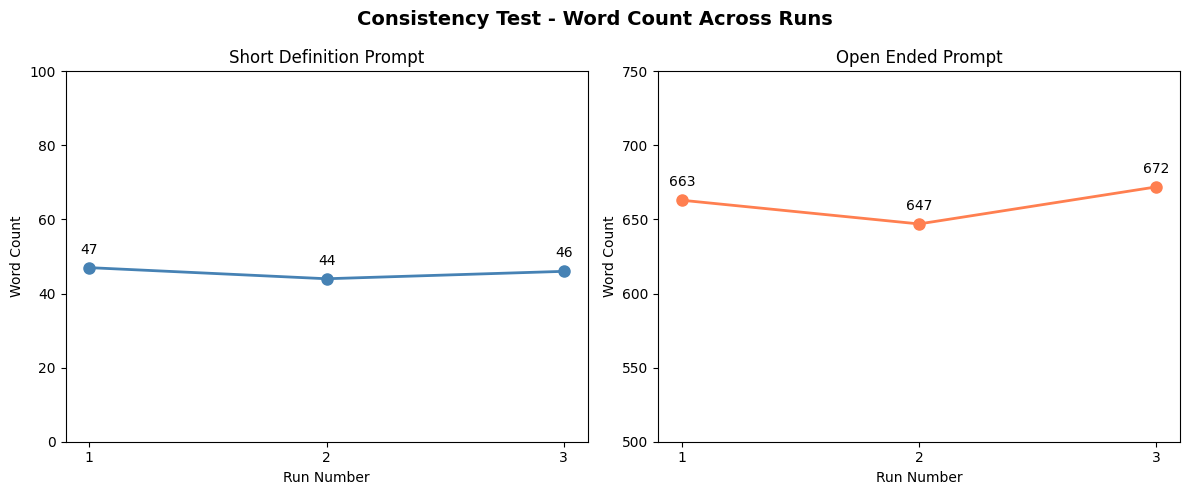

Consistency chart saved ✅
Consistency data saved ✅


In [ ]:
# visualize consistency results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Consistency Test - Word Count Across Runs", fontsize=14, fontweight="bold")

# Plot 1 - Short Definition
axes[0].plot([1,2,3], df1["word_count"], marker='o',
             color="steelblue", linewidth=2, markersize=8)
axes[0].set_xlabel("Run Number")
axes[0].set_ylabel("Word Count")
axes[0].set_title("Short Definition Prompt")
axes[0].set_xticks([1,2,3])
axes[0].set_ylim(0, 100)
for i, val in enumerate(df1["word_count"]):
    axes[0].annotate(str(val), (i+1, val), textcoords="offset points",
                     xytext=(0,10), ha="center")

# Plot 2 - Open Ended
axes[1].plot([1,2,3], df2["word_count"], marker='o',
             color="coral", linewidth=2, markersize=8)
axes[1].set_title("Open Ended Prompt")
axes[1].set_xlabel("Run Number")
axes[1].set_ylabel("Word Count")
axes[1].set_xticks([1,2,3])
axes[1].set_ylim(500, 750)
for i, val in enumerate(df2["word_count"]):
    axes[1].annotate(str(val), (i+1, val), textcoords="offset points",
                     xytext=(0,10), ha="center")

plt.tight_layout()
plt.savefig(SAVE_PATH + "chart_consistency_test.png")
plt.show()
print("Consistency chart saved ✅")

# Save consistency results
df1.to_csv(SAVE_PATH + "consistency_short_prompt.csv", index=False)
df2.to_csv(SAVE_PATH + "consistency_open_prompt.csv", index=False)
print("Consistency data saved ✅")

## Findings: Consistency Test

**Model tested:** gemini-flash-latest
**Date:** May 2026
**Test type:** Same prompt repeated 3 times

### Results

| Prompt Type     | Avg Words | Variance | Verdict      |
|-----------------|-----------|----------|--------------|
| Short Definition| 46 words  | 3 words  | ✅ Consistent |
| Open Ended      | 661 words | 25 words | ✅ Consistent |

### Key Findings

1. The model is highly consistent on short, specific prompts ..
   variance of only 3 words across 3 runs.

2. Open ended prompts produce longer responses but remain
   consistent .. variance of 25 words across 661 word responses
   is less than 4% deviation.

3. The model defaults to verbosity on open ended questions ..
   averaging 661 words with no instruction on length.

### Recommendation
When deploying this model in governance tools, constrain
output length explicitly in the prompt. Example:
"Answer in maximum 3 sentences."